# Logistic Regression – Crime Case Classification

Predict whether a criminal case is **closed** (Yes/No) using `crime_train.csv` for training and `crime_test.csv` for evaluation. **Do not use the test file to train the model.** Model implemented from scratch; training and testing accuracy reported each epoch.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

/Users/sooryas/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/sooryas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# From-scratch helpers (NumPy only): sigmoid, BCE cost, gradient, accuracy
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def bce_cost(y, p):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def bce_gradient(X, y, p):
    n = X.shape[0]
    return (1.0 / n) * (X.T @ (p - y))

def accuracy(y_true, p_pred):
    y_pred = (p_pred >= 0.5).astype(np.float64)
    return np.mean(y_pred == y_true)

In [3]:
# Load data (same folder as notebook)
train_df = pd.read_csv("crime_train.csv")
test_df = pd.read_csv("crime_test.csv")
target_col = "closed"
cat_cols = ["city", "crime_description", "sex", "weapon", "domain"]
num_cols = ["area", "age", "police_department"]

# Train: target and features
train_df = train_df.dropna(subset=[target_col])
y_train = (train_df[target_col] == "Yes").astype(np.float64).values.ravel()
train_num = train_df[num_cols].fillna(train_df[num_cols].median())
train_dummies = pd.get_dummies(train_df[cat_cols], drop_first=False, dtype=float)
X_train_df = pd.concat([train_num.reset_index(drop=True), train_dummies.reset_index(drop=True)], axis=1)
dummy_cols = list(train_dummies.columns)
X_train_raw = X_train_df.values.astype(np.float64)
train_mean = np.mean(X_train_raw, axis=0)
train_std = np.std(X_train_raw, axis=0)
train_std[train_std == 0] = 1.0
X_train_scaled = (X_train_raw - train_mean) / train_std
X_train = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])

# Test: align columns to train, then standardize with train mean/std
test_df_clean = test_df.dropna(subset=[target_col])
y_test = (test_df_clean[target_col] == "Yes").astype(np.float64).values.ravel()
test_num = test_df_clean[num_cols].fillna(train_df[num_cols].median())
test_dummies = pd.get_dummies(test_df_clean[cat_cols], drop_first=False, dtype=float)
for c in dummy_cols:
    if c not in test_dummies.columns:
        test_dummies[c] = 0
test_dummies = test_dummies[dummy_cols]
X_test_df = pd.concat([test_num.reset_index(drop=True), test_dummies.reset_index(drop=True)], axis=1)
X_test_raw = X_test_df.values.astype(np.float64)
X_test_clean_scaled = (X_test_raw - train_mean) / train_std
X_test_clean = np.hstack([np.ones((X_test_clean_scaled.shape[0], 1)), X_test_clean_scaled])
print(f"Training samples: {len(y_train)}, Test samples: {len(y_test)}, Features: {X_train.shape[1]}")

Training samples: 22489, Test samples: 9639, Features: 67


In [4]:
# Train with gradient descent (train only on train data)
n_epochs = 300
lr = 0.1
w = np.zeros(X_train.shape[1])
costs = []

for epoch in range(1, n_epochs + 1):
    p_train = sigmoid(X_train @ w)
    cost = bce_cost(y_train, p_train)
    costs.append(cost)
    grad = bce_gradient(X_train, y_train, p_train)
    w = w - lr * grad
    acc_train = accuracy(y_train, p_train)
    p_test = sigmoid(X_test_clean @ w)
    acc_test = accuracy(y_test, p_test)
    print(f"Epoch {epoch}: cost = {cost:.4f}, train accuracy = {acc_train:.4f}, test accuracy = {acc_test:.4f}")

Epoch 1: cost = 0.6931, train accuracy = 0.5004, test accuracy = 0.4944
Epoch 2: cost = 0.6931, train accuracy = 0.5162, test accuracy = 0.4944
Epoch 3: cost = 0.6930, train accuracy = 0.5163, test accuracy = 0.4943
Epoch 4: cost = 0.6930, train accuracy = 0.5158, test accuracy = 0.4940
Epoch 5: cost = 0.6930, train accuracy = 0.5163, test accuracy = 0.4946
Epoch 6: cost = 0.6929, train accuracy = 0.5166, test accuracy = 0.4944
Epoch 7: cost = 0.6929, train accuracy = 0.5161, test accuracy = 0.4946
Epoch 8: cost = 0.6928, train accuracy = 0.5158, test accuracy = 0.4940
Epoch 9: cost = 0.6928, train accuracy = 0.5159, test accuracy = 0.4940
Epoch 10: cost = 0.6928, train accuracy = 0.5155, test accuracy = 0.4942
Epoch 11: cost = 0.6928, train accuracy = 0.5151, test accuracy = 0.4949
Epoch 12: cost = 0.6927, train accuracy = 0.5144, test accuracy = 0.4947
Epoch 13: cost = 0.6927, train accuracy = 0.5145, test accuracy = 0.4954
Epoch 14: cost = 0.6927, train accuracy = 0.5149, test accur

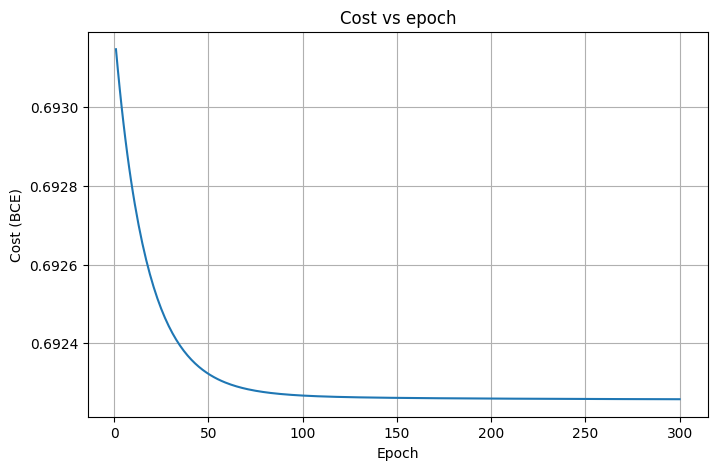

In [5]:
# Plot cost vs epoch
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(costs) + 1), costs)
plt.xlabel("Epoch")
plt.ylabel("Cost (BCE)")
plt.title("Cost vs epoch")
plt.grid(True)
plt.show()

In [6]:
# Final evaluation: accuracy on test set (from scratch)
p_test = sigmoid(X_test_clean @ w)
test_accuracy = accuracy(y_test, p_test)
print(f"Final test accuracy: {test_accuracy:.4f}")

Final test accuracy: 0.4903


## Results

Logistic regression is implemented **from scratch** (NumPy only; no sklearn). Training and testing **accuracy** are reported after each epoch. The plot shows binary cross-entropy cost vs epoch. Final evaluation metric is test **accuracy**.